In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
conn = sqlite3.connect('D:\jai\Python-Workspace\Credit-Path-AI\database\creditpathai.db')
df = pd.read_sql("SELECT * FROM preprocessed_data", conn)
df.head()

,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,residentialState,yearsEmployment,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current,NM,10+ years,...,6,11,9.0,6,14301,49.02,0,19,10,0
1,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current,WA,2-5 years,...,22,8,7.0,4,18262,72.40,1,0,0,0
2,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current,MS,< 1 year,...,5,8,5.0,5,10799,66.27,0,1,1,0
3,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current,TX,6-9 years,...,12,14,7.0,3,15272,61.05,1,0,0,3
4,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current,MA,2-5 years,...,4,21,19.0,10,19316,56.39,2,14,7,1


#### Basic information of dataset as whole

In [5]:
df.shape

(100000, 24)

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                100000 non-null  int64  
 1   loanId                    100000 non-null  int64  
 2   memberId                  100000 non-null  int64  
 3   date                      100000 non-null  object 
 4   purpose                   100000 non-null  object 
 5   isJointApplication        100000 non-null  float64
 6   loanAmount                100000 non-null  float64
 7   term                      100000 non-null  object 
 8   interestRate              100000 non-null  float64
 9   monthlyPayment            100000 non-null  int64  
 10  grade                     100000 non-null  object 
 11  loanStatus                100000 non-null  object 
 12  residentialState          100000 non-null  object 
 13  yearsEmployment           100000 non-null  ob

In [ ]:
### No of categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print("Categorical features : ", cat_features)
print("No of categorical features : ", len(cat_features))

Categorical features :  ['purpose', 'term', 'grade', 'loanStatus', 'residentialState', 'yearsEmployment', 'homeOwnership']
No of categorical features :  7


In [ ]:
## No of numerical features (discrete + continuous)
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print("Numerical features : ", num_features)
print("No of Numerical features : ", len(num_features))

Numerical features :  ['isJointApplication', 'loanAmount', 'interestRate', 'monthlyPayment', 'annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon']
No of Numerical features :  17


In [38]:
### Discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=50]
print("Discrete Features : ",discrete_features)
print('Num of Discrete Features :',len(discrete_features))

Discrete Features :  ['isJointApplication', 'incomeVerified', 'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year', 'numDerogatoryRec', 'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon']
Num of Discrete Features : 10


In [39]:
### Continuous features
continuous_features = [feature for feature in df.columns if feature not in discrete_features and df[feature].dtype != 'O']
print("Continuous Features : ",continuous_features)
print("No of continuous features : ", len(continuous_features))

Continuous Features :  ['loanAmount', 'interestRate', 'monthlyPayment', 'annualIncome', 'dtiRatio', 'revolvingBalance', 'revolvingUtilizationRate']
No of continuous features :  7


In [ ]:
## Overall Statistics of numerical continuous  features
df[continuous_features].describe()

,loanAmount,interestRate,monthlyPayment,annualIncome,dtiRatio,revolvingBalance,revolvingUtilizationRate
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,20657.935830,10.977798,552.448620,54718.013140,17.281603,14848.970210,65.090856
std,4707.703905,3.904456,165.072058,3178.627286,5.100633,2507.838336,15.286859
min,1618.000000,4.020000,42.000000,38328.000000,0.000000,4291.000000,0.000000
25%,17517.000000,7.980000,434.000000,52648.000000,13.820000,13150.000000,54.520000
50%,20600.000000,10.460000,534.000000,54781.000000,17.240000,14852.000000,65.180000
75%,23750.000000,13.440000,655.000000,56866.000000,20.720000,16537.250000,75.570000
max,42403.000000,31.700000,1575.000000,69553.000000,40.510000,25802.000000,100.000000


### Univariate Analysis

Numerical Continuous Features

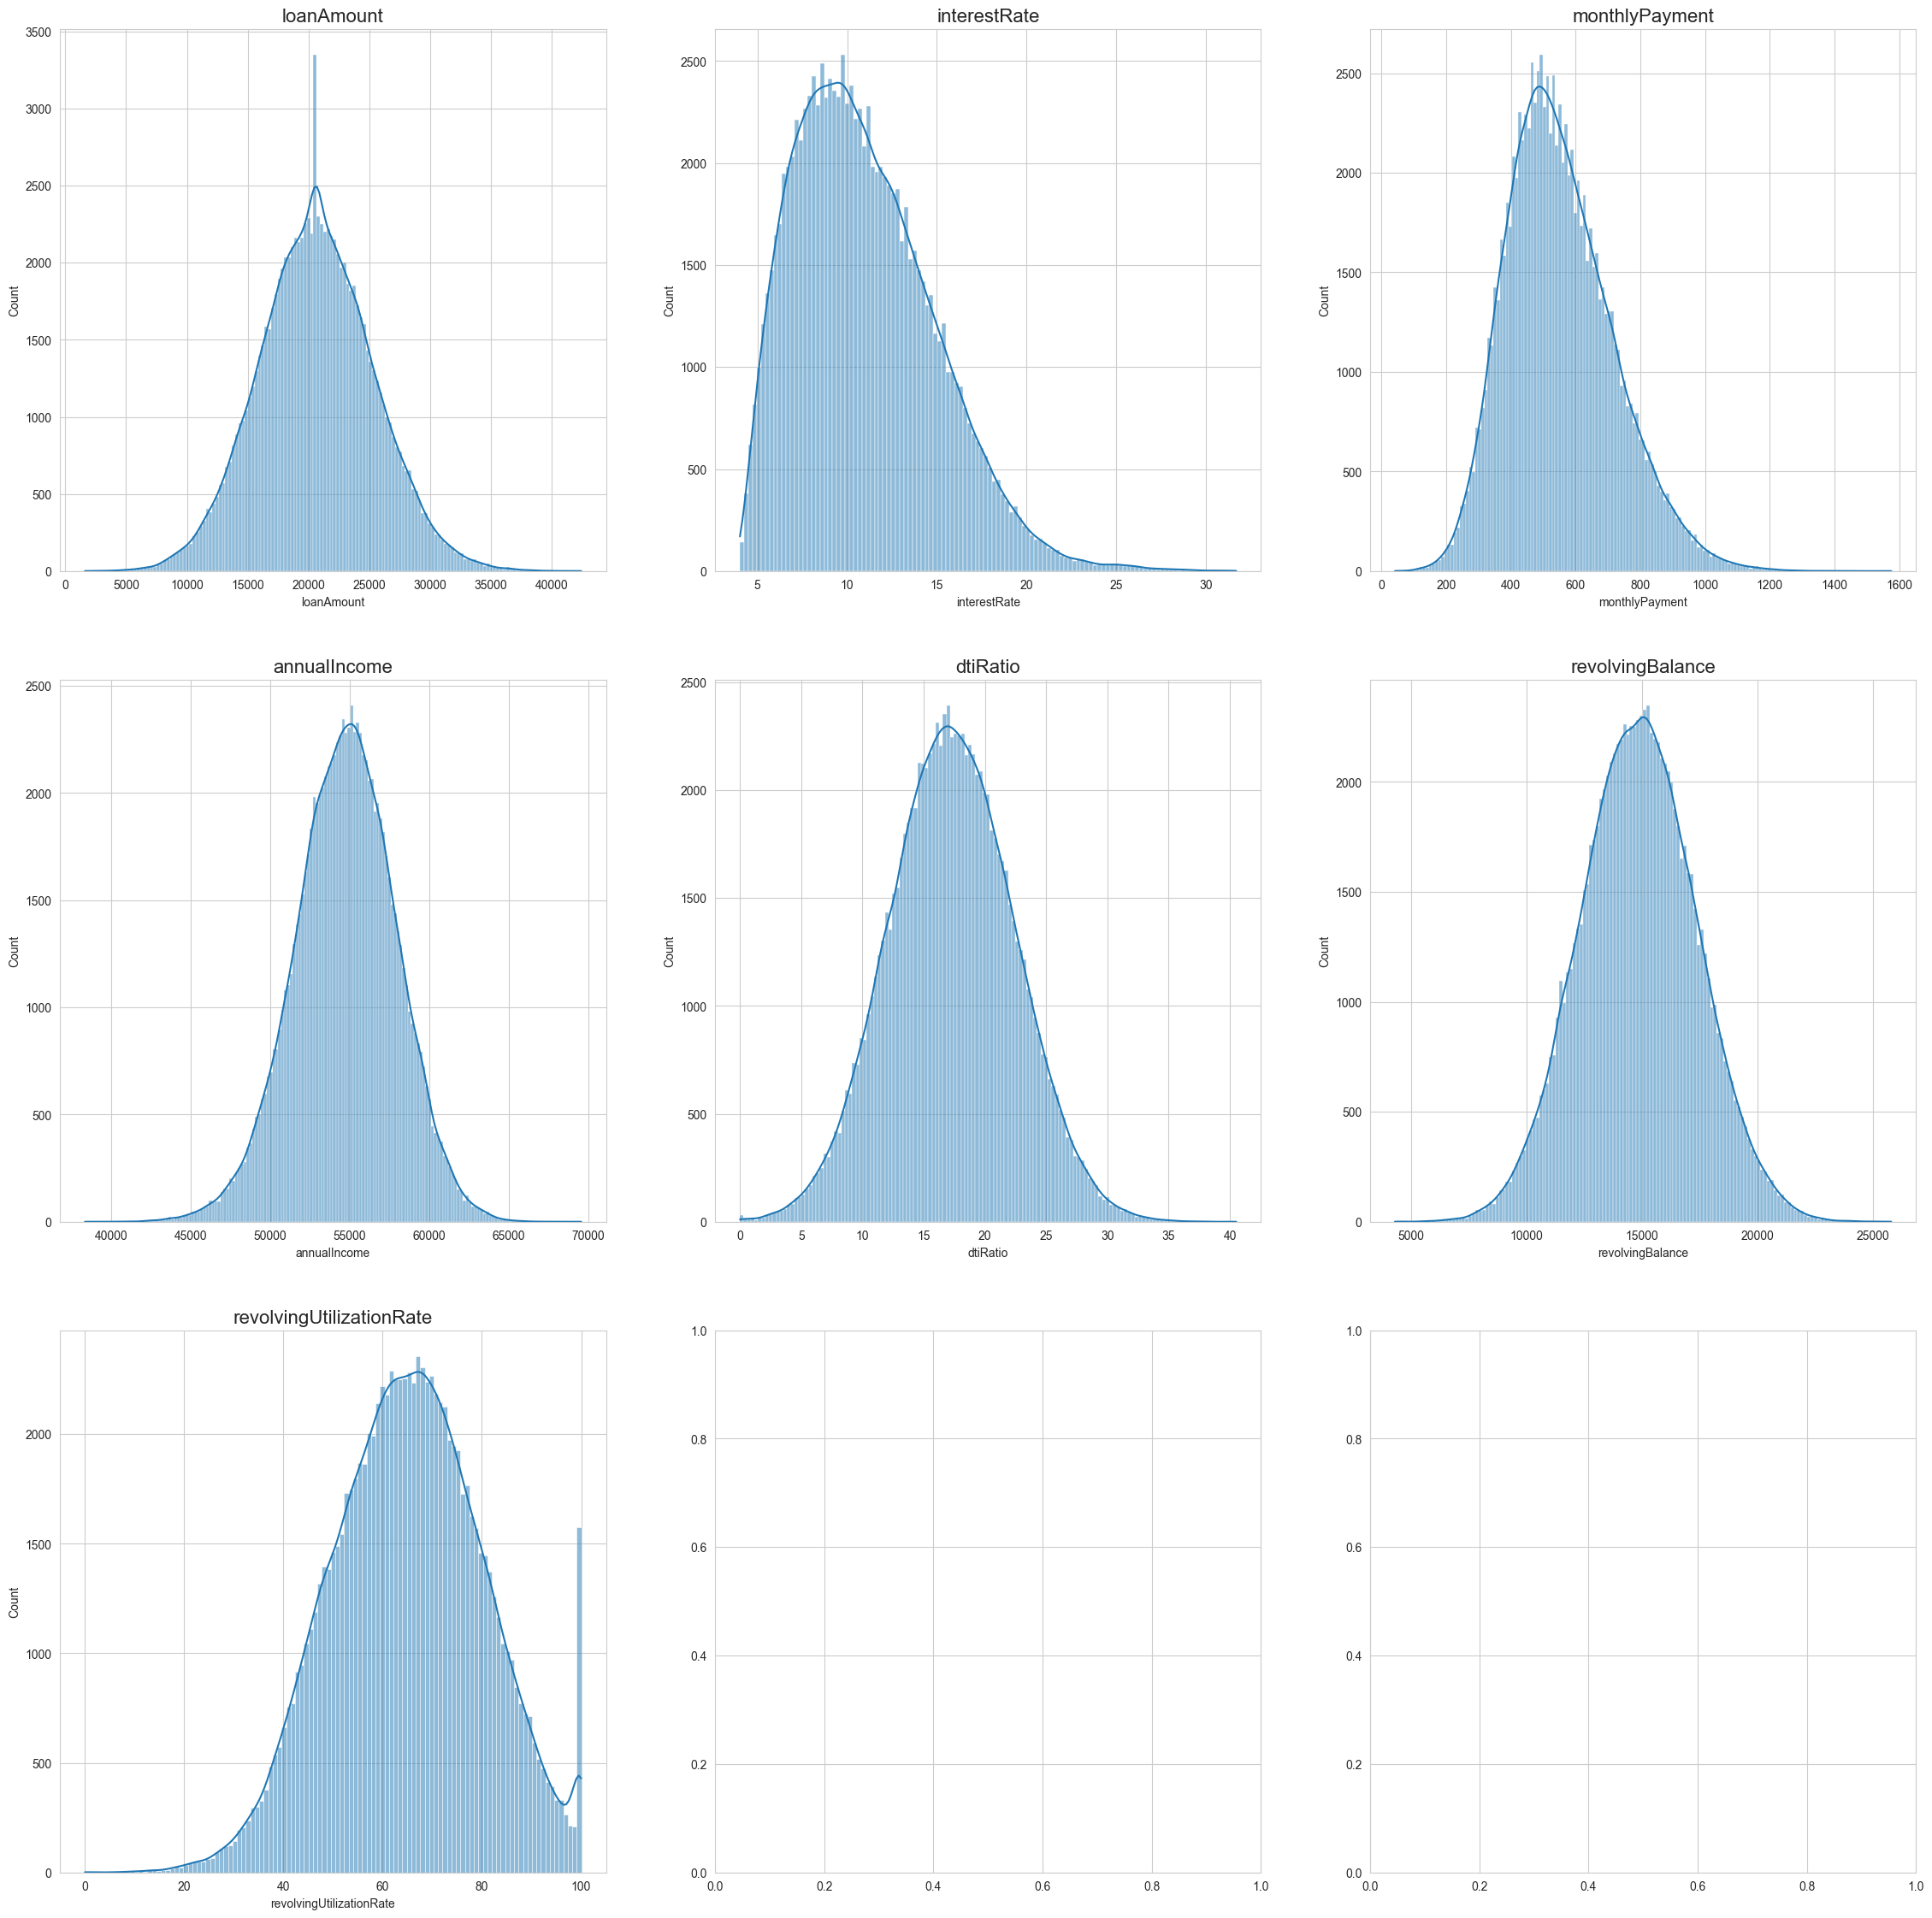

In [29]:
fig, ax = plt.subplots(3,3, figsize = (28,28))
sns.set_style('whitegrid')
for i, col in enumerate(continuous_features):
    r = i // 3
    c = i % 3
    sns.histplot(df[col], kde=True, ax = ax[r,c])
    ax[r,c].set_title(col, fontsize = 16)
# plt.tight_layout()
plt.show()

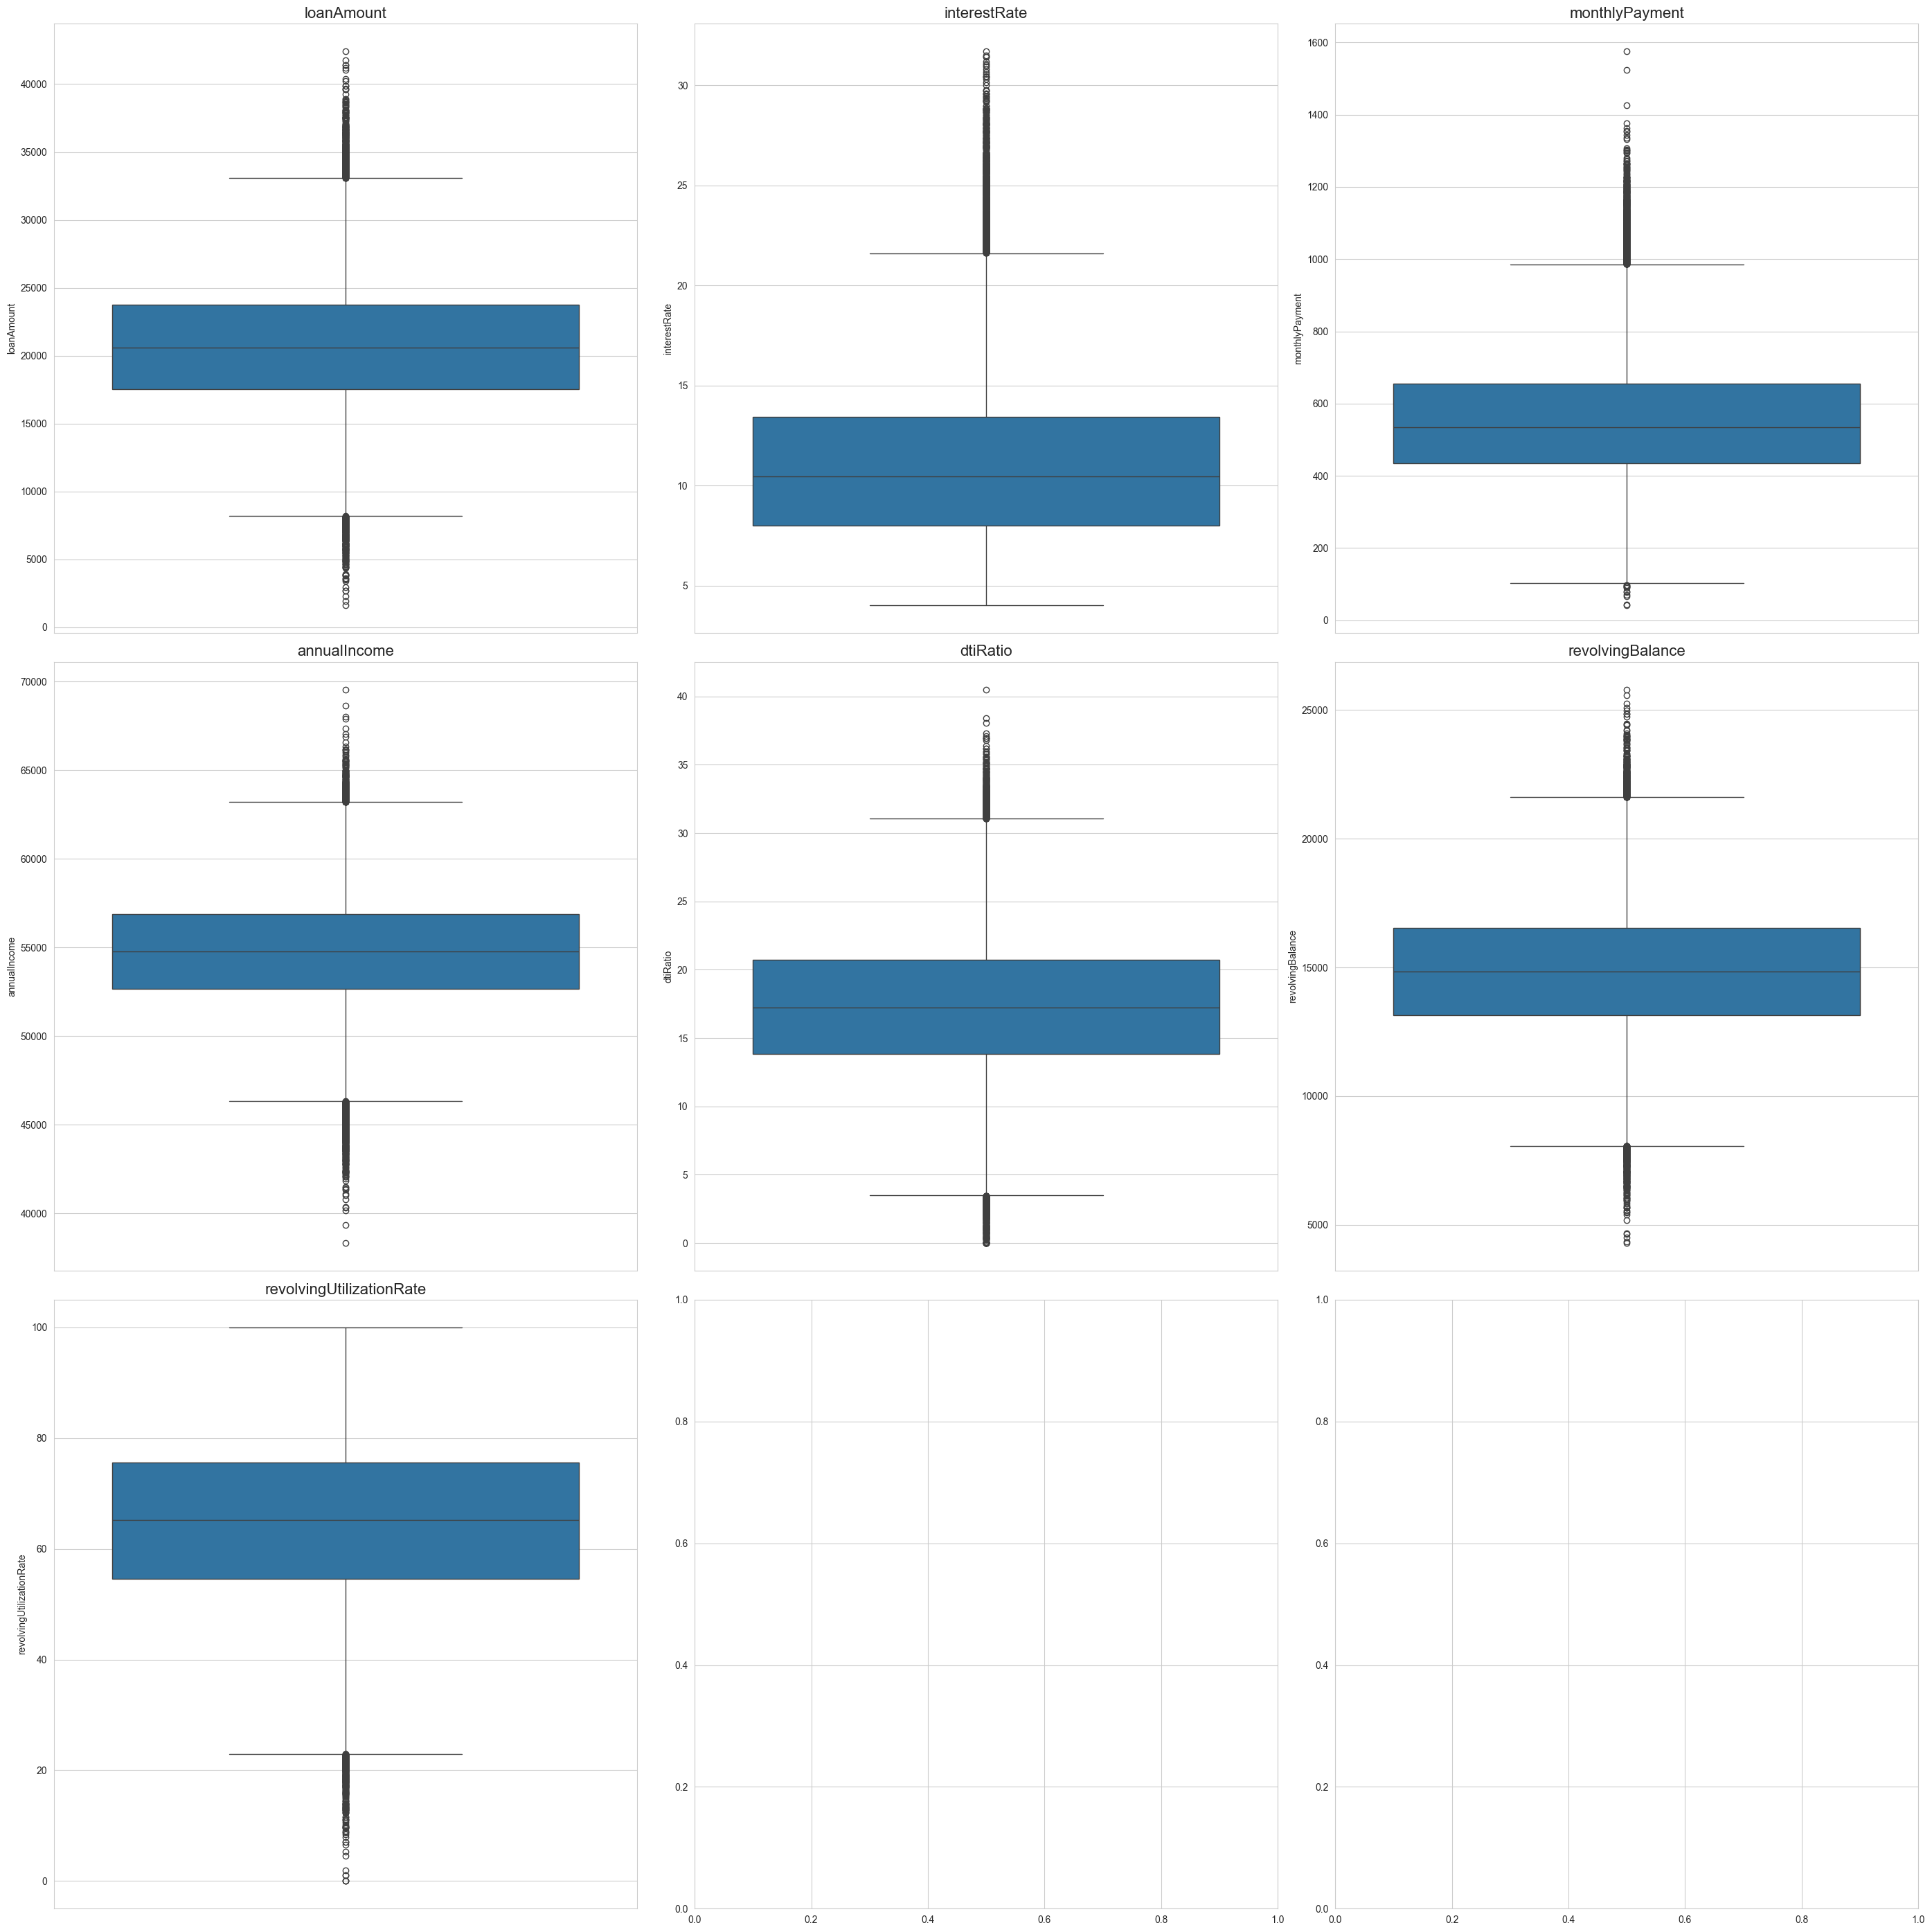

In [31]:
fig, ax = plt.subplots(3,3, figsize = (28,28))
sns.set_style('whitegrid')
for i, col in enumerate(continuous_features):
    r = i // 3
    c = i % 3
    sns.boxplot(df[col],ax = ax[r,c])
    ax[r,c].set_title(col, fontsize = 16)
plt.tight_layout()
plt.show()

#### Bivariate Analysis

In [33]:
X = df.drop('loanStatus', axis = 1)
Y = df['loanStatus']


In [34]:
X.head()

,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,residentialState,yearsEmployment,homeOwnership,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,NM,10+ years,rent,...,6,11,9.0,6,14301,49.02,0,19,10,0
1,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,WA,2-5 years,rent,...,22,8,7.0,4,18262,72.40,1,0,0,0
2,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,MS,< 1 year,rent,...,5,8,5.0,5,10799,66.27,0,1,1,0
3,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,TX,6-9 years,own,...,12,14,7.0,3,15272,61.05,1,0,0,3
4,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,MA,2-5 years,rent,...,4,21,19.0,10,19316,56.39,2,14,7,1


In [35]:
Y.head()

0    Current
1    Current
2    Current
3    Current
4    Current
Name: loanStatus, dtype: object

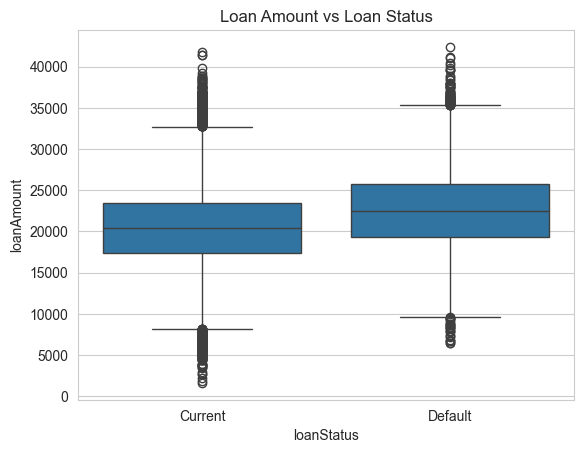

In [36]:
sns.boxplot(x="loanStatus", y="loanAmount", data=df)

plt.title("Loan Amount vs Loan Status")
plt.show()

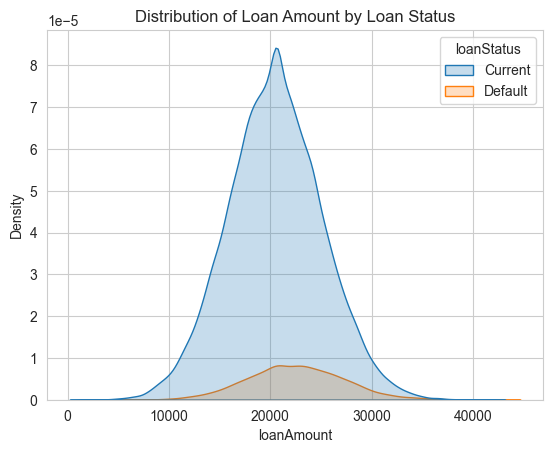

In [37]:
sns.kdeplot(data=df, x="loanAmount", hue="loanStatus", fill=True)

plt.title("Distribution of Loan Amount by Loan Status")
plt.show()

How Various Categorical Features affect loanStatus <br>
This will be helpful in doing proper encoding of these features

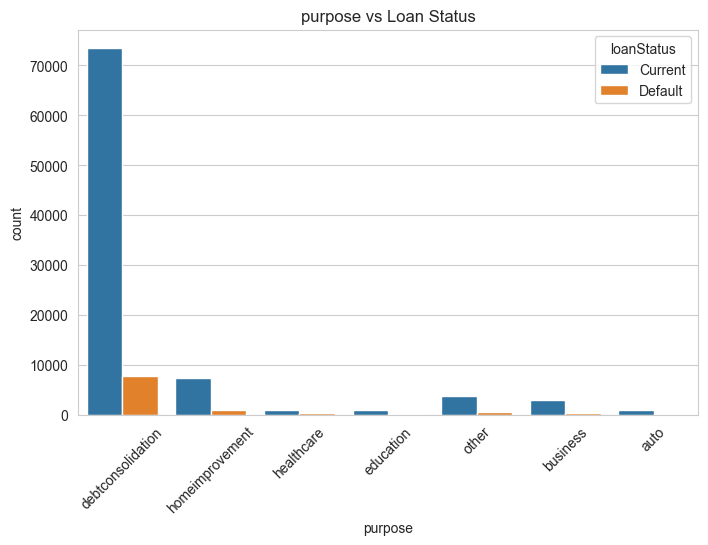

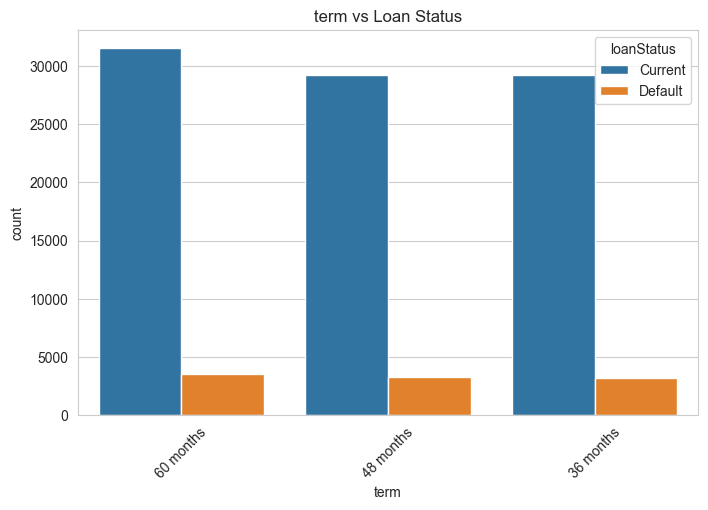

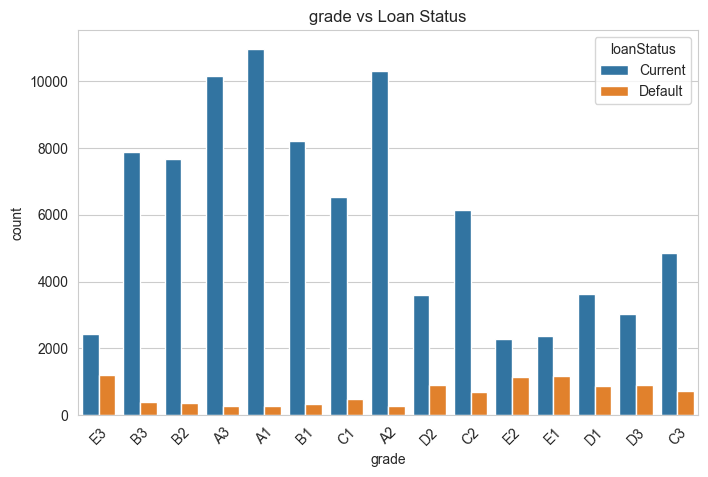

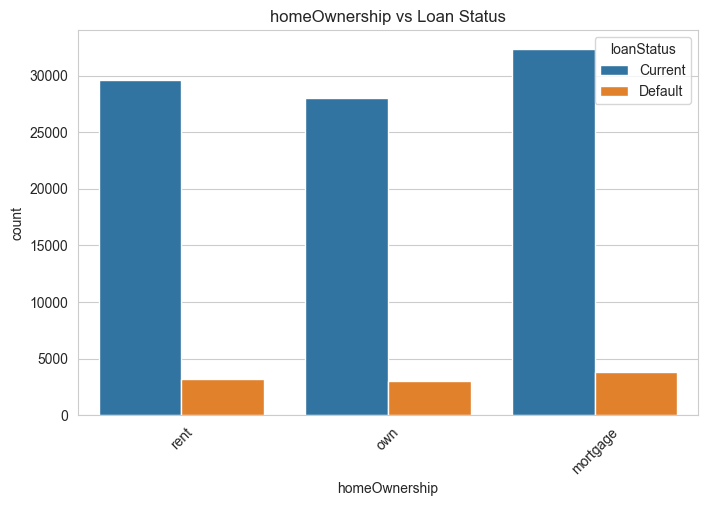

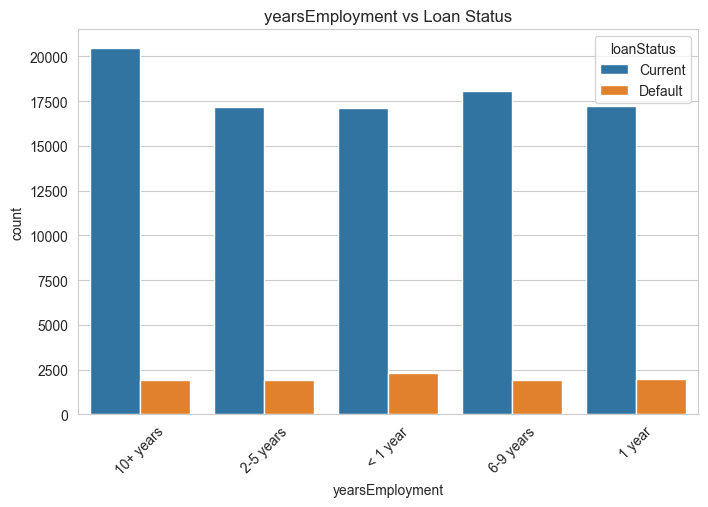

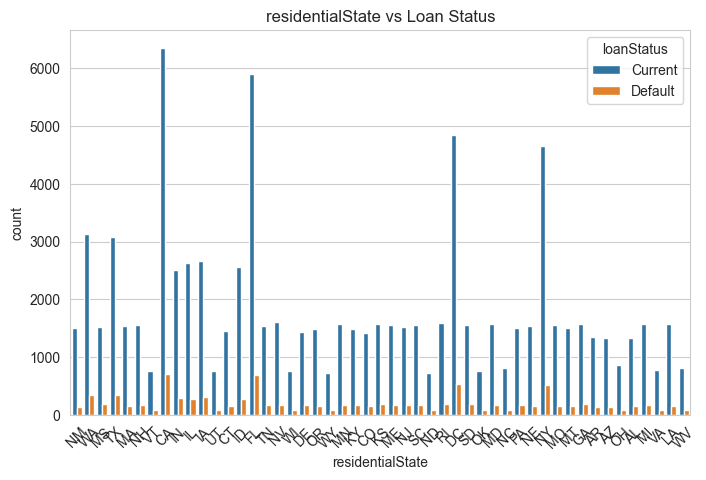

In [42]:
cat_features = ['purpose','term','grade','homeOwnership','yearsEmployment','residentialState']

for col in cat_features:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, hue='loanStatus', data=df)
    
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.show()

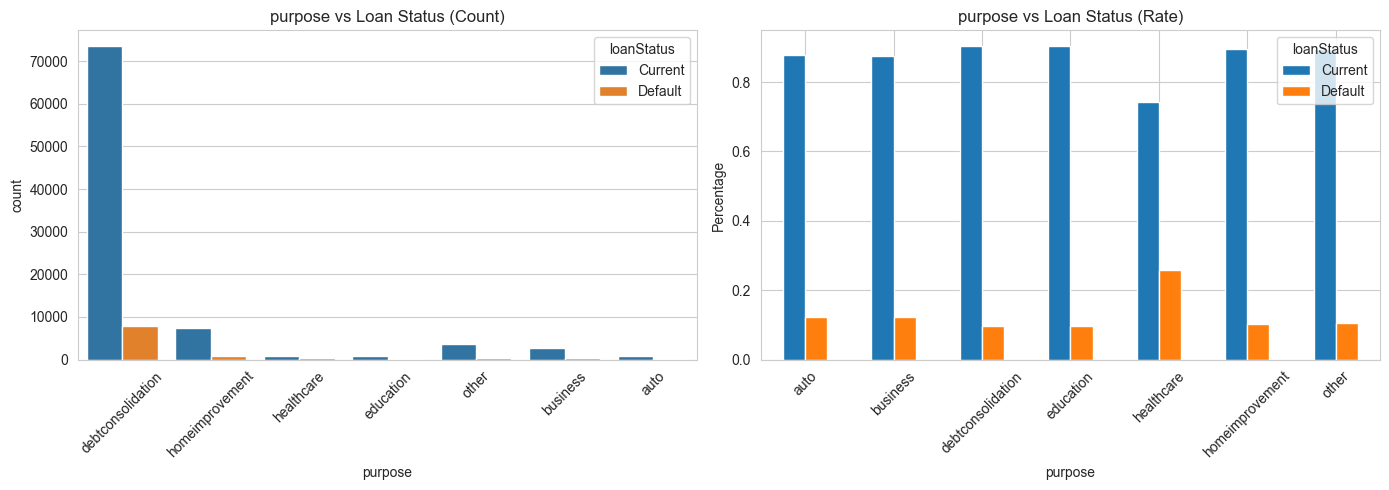

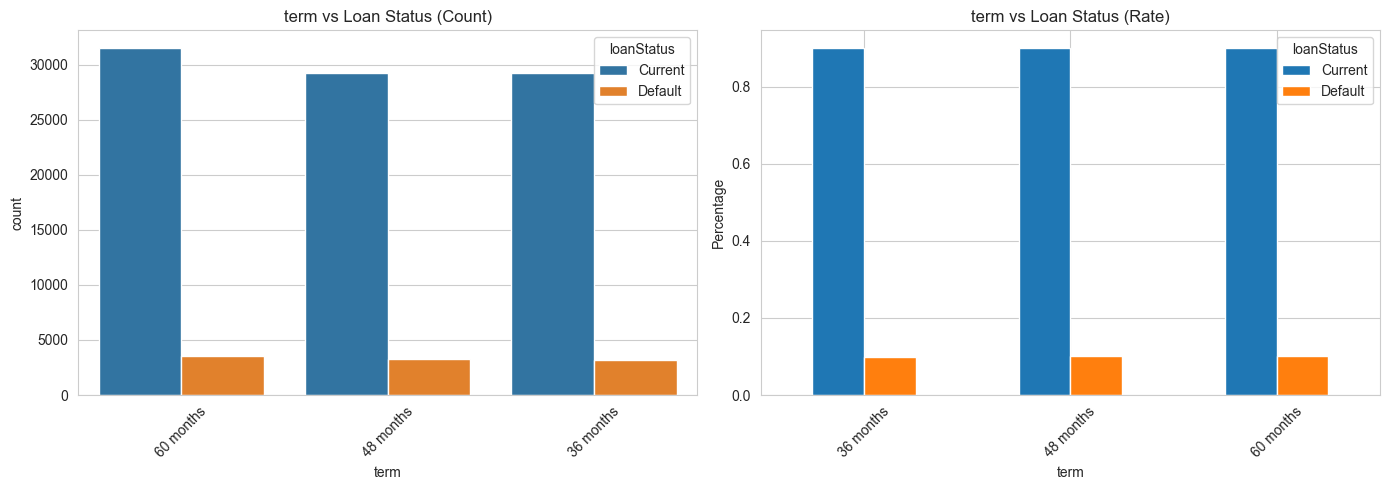

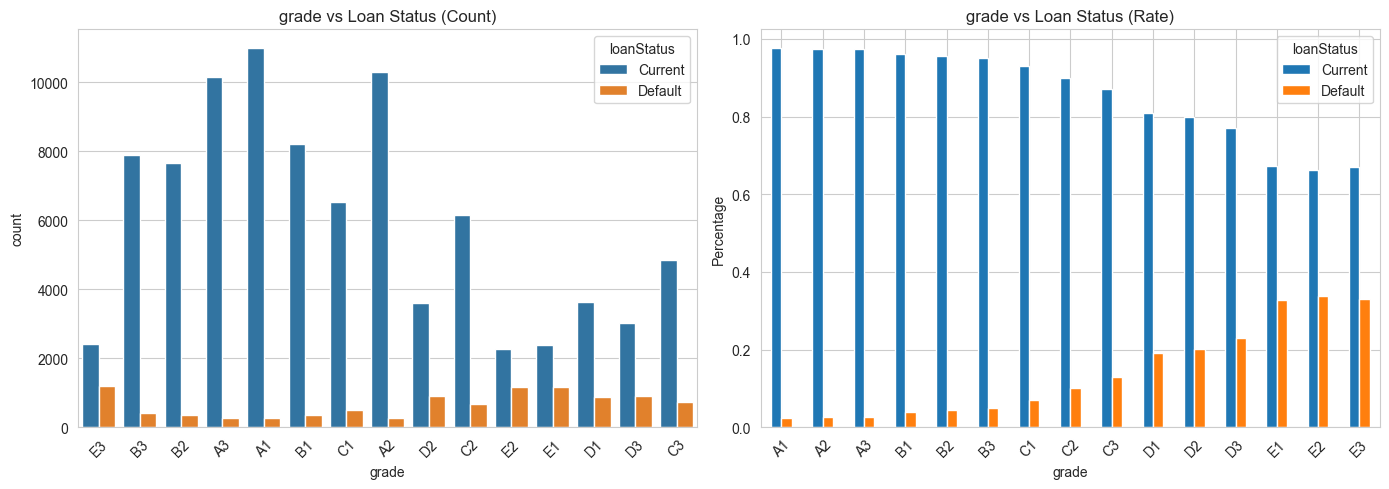

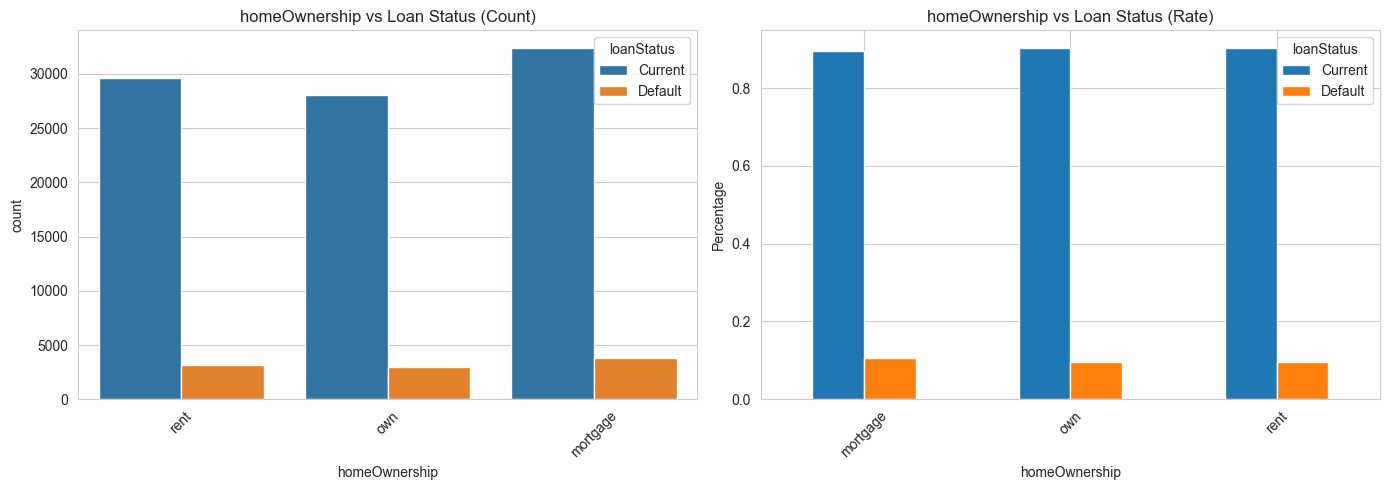

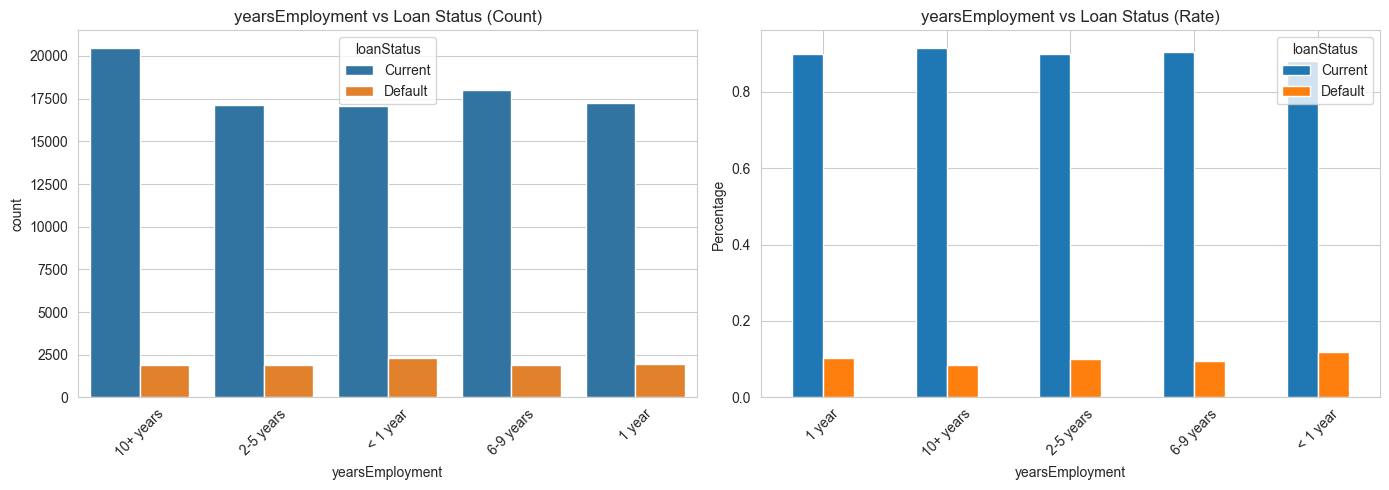

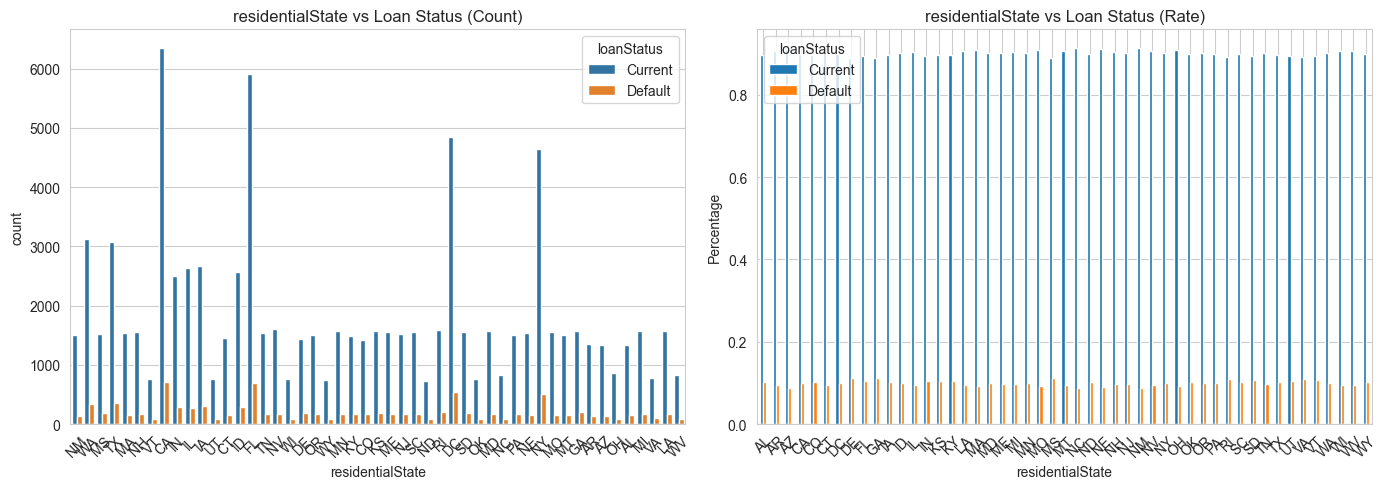

In [43]:
for col in cat_features:

    fig, ax = plt.subplots(1,2, figsize=(14,5))

    # Countplot
    sns.countplot(data=df, x=col, hue='loanStatus', ax=ax[0])
    ax[0].set_title(f'{col} vs Loan Status (Count)')
    ax[0].tick_params(axis='x', rotation=45)

    # Default Rate Plot
    default_rate = pd.crosstab(df[col], df['loanStatus'], normalize='index')
    default_rate.plot(kind='bar', ax=ax[1])

    ax[1].set_title(f'{col} vs Loan Status (Rate)')
    ax[1].set_ylabel("Percentage")
    ax[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [45]:
emp_status = pd.crosstab(
    df['yearsEmployment'],
    df['loanStatus'],
    normalize='index'
) * 100

print(emp_status)

loanStatus         Current    Default
yearsEmployment                      
1 year           89.787101  10.212899
10+ years        91.451159   8.548841
2-5 years        89.954865  10.045135
6-9 years        90.423665   9.576335
< 1 year         88.124323  11.875677


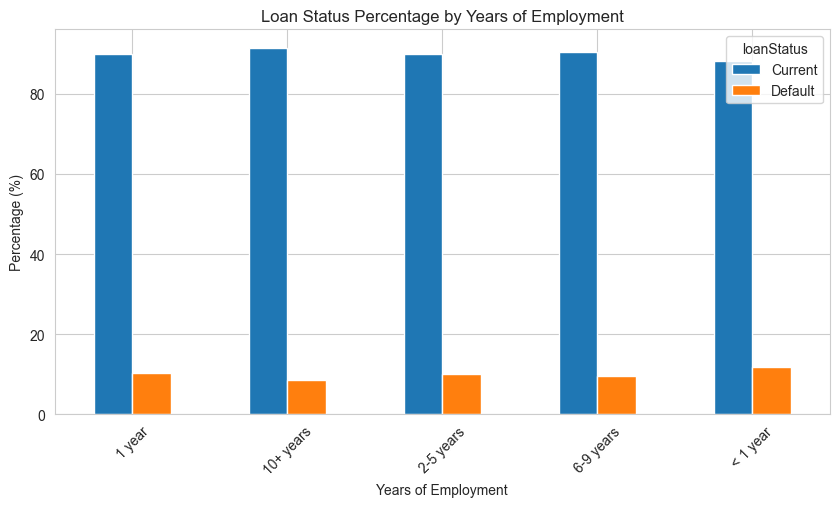

In [46]:
emp_status.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Loan Status Percentage by Years of Employment")
plt.ylabel("Percentage (%)")
plt.xlabel("Years of Employment")
plt.xticks(rotation=45)

plt.show()

Final Encoding Techniques to use -: <br>
1. purpose : One Hot Encoding <br>
2. term : One Hot Encoding <br>
3. grade : Ordinal Encoding <br>
4. homeOwnership : One Hot Encoding <br>
5. yearEmployment : One Hot Encoding <br>
6. residentialState : Target Ordinal Encoding <br>
7. loanStatus (target feature) : LabelEncoding (0 - default, 1 - Current) 

In [195]:
numeric_cols = df.select_dtypes(include=['int', 'float']).columns
print(numeric_cols)

Index(['loanId', 'memberId', 'isJointApplication', 'loanAmount',
       'interestRate', 'monthlyPayment', 'annualIncome', 'incomeVerified',
       'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines',
       'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance',
       'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years',
       'numChargeoff1year', 'numInquiries6Mon'],
      dtype='object')


In [196]:
df['loanStatus'].value_counts()

loanStatus
Current    89996
Default    10004
Name: count, dtype: int64

In [197]:
df['loanStatus'] = df['loanStatus'].map(lambda x : 0 if x == 'Default' else 1)

In [198]:
df['loanStatus'].value_counts()

loanStatus
1    89996
0    10004
Name: count, dtype: int64

In [199]:
df['loanId'].corr(df['loanStatus'])

0.0020316184183540925

In [200]:
df['memberId'].corr(df['loanStatus'])

0.0033228895551289197

In [201]:
df.drop(['loanId', 'memberId'], axis = 1,  inplace=True)
df.head()

,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,residentialState,yearsEmployment,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,1,NM,10+ years,...,6,11,9.0,6,14301,49.02,0,19,10,0
1,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,1,WA,2-5 years,...,22,8,7.0,4,18262,72.40,1,0,0,0
2,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,1,MS,< 1 year,...,5,8,5.0,5,10799,66.27,0,1,1,0
3,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,1,TX,6-9 years,...,12,14,7.0,3,15272,61.05,1,0,0,3
4,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,1,MA,2-5 years,...,4,21,19.0,10,19316,56.39,2,14,7,1


In [202]:
df['purpose'].value_counts()

purpose
debtconsolidation    81344
homeimprovement       8116
other                 4118
business              3210
healthcare            1229
education             1003
auto                   980
Name: count, dtype: int64

In [203]:
pd.crosstab(df['purpose'], df['loanStatus'])

loanStatus,0,1
purpose,,
auto,120,860
business,396,2814
debtconsolidation,7808,73536
education,97,906
healthcare,317,912
homeimprovement,838,7278
other,428,3690


One hot encoding

In [204]:
df = pd.get_dummies(df, columns=['purpose'],dtype=int)
df.head()

,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,residentialState,yearsEmployment,homeOwnership,...,numDelinquency2Years,numChargeoff1year,numInquiries6Mon,purpose_auto,purpose_business,purpose_debtconsolidation,purpose_education,purpose_healthcare,purpose_homeimprovement,purpose_other
0,0.0,25190.0,60 months,6.25,490,E3,1,NM,10+ years,rent,...,19,10,0,0,0,1,0,0,0,0
1,0.0,21189.0,60 months,10.49,455,B3,1,WA,2-5 years,rent,...,0,0,0,0,0,1,0,0,0,0
2,0.0,29908.0,60 months,9.11,622,B2,1,MS,< 1 year,rent,...,1,1,0,0,0,1,0,0,0,0
3,0.0,13053.0,48 months,11.89,343,B3,1,TX,6-9 years,own,...,0,0,3,0,0,0,0,0,1,0
4,0.0,24613.0,60 months,15.13,587,A3,1,MA,2-5 years,rent,...,14,7,1,0,0,1,0,0,0,0


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   isJointApplication         100000 non-null  float64
 1   loanAmount                 100000 non-null  float64
 2   term                       100000 non-null  object 
 3   interestRate               100000 non-null  float64
 4   monthlyPayment             100000 non-null  int64  
 5   grade                      100000 non-null  object 
 6   loanStatus                 100000 non-null  int64  
 7   residentialState           100000 non-null  object 
 8   yearsEmployment            100000 non-null  object 
 9   homeOwnership              100000 non-null  object 
 10  annualIncome               100000 non-null  int64  
 11  incomeVerified             100000 non-null  int64  
 12  dtiRatio                   100000 non-null  float64
 13  lengthCreditHistory        100

In [206]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['term', 'grade', 'residentialState', 'yearsEmployment',
       'homeOwnership'],
      dtype='object')


In [207]:
df['term'].value_counts()

term
60 months    35042
48 months    32486
36 months    32472
Name: count, dtype: int64

In [208]:
pd.crosstab(df['term'],df['loanStatus'])

loanStatus,0,1
term,,
36 months,3221,29251
48 months,3276,29210
60 months,3507,31535


In [209]:
df['term'] = df['term'].str.replace(' months', '').astype(int)
df['term'].value_counts()

term
60    35042
48    32486
36    32472
Name: count, dtype: int64

In [210]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['grade', 'residentialState', 'yearsEmployment', 'homeOwnership'], dtype='object')


In [211]:
df['grade'].value_counts()

grade
A1    11251
A2    10574
A3    10416
B1     8553
B3     8279
B2     8014
C1     7030
C2     6826
C3     5573
D2     4513
D1     4488
D3     3917
E3     3614
E1     3530
E2     3422
Name: count, dtype: int64

In [212]:
pd.crosstab(df['grade'], df['loanStatus'])

loanStatus,0,1
grade,,
A1,275,10976
A2,280,10294
A3,274,10142
B1,341,8212
B2,355,7659
B3,405,7874
C1,492,6538
C2,686,6140
C3,726,4847


In [213]:
df['grade_letter'] = df['grade'].str[0]
df['grade_number'] = df['grade'].str[1].astype(int)

df['grade_letter'] = df['grade_letter'].map({
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5
})

In [214]:
df['grade_encoded'] = (df['grade_letter'] - 1) * 5 + df['grade_number']

In [215]:
df['grade'] 
df['grade_letter']
df['grade_number']
df['grade_encoded']

0        23
1         8
2         7
3         8
4         3
         ..
99995     2
99996     1
99997     2
99998    13
99999     2
Name: grade_encoded, Length: 100000, dtype: int64

In [216]:
df.drop(columns=['grade', 'grade_letter', 'grade_number'], inplace=True)

In [217]:
df.head()

,isJointApplication,loanAmount,term,interestRate,monthlyPayment,loanStatus,residentialState,yearsEmployment,homeOwnership,annualIncome,...,numChargeoff1year,numInquiries6Mon,purpose_auto,purpose_business,purpose_debtconsolidation,purpose_education,purpose_healthcare,purpose_homeimprovement,purpose_other,grade_encoded
0,0.0,25190.0,60,6.25,490,1,NM,10+ years,rent,56471,...,10,0,0,0,1,0,0,0,0,23
1,0.0,21189.0,60,10.49,455,1,WA,2-5 years,rent,55038,...,0,0,0,0,1,0,0,0,0,8
2,0.0,29908.0,60,9.11,622,1,MS,< 1 year,rent,56610,...,1,0,0,0,1,0,0,0,0,7
3,0.0,13053.0,48,11.89,343,1,TX,6-9 years,own,54887,...,0,3,0,0,0,0,0,1,0,8
4,0.0,24613.0,60,15.13,587,1,MA,2-5 years,rent,53522,...,7,1,0,0,1,0,0,0,0,3


In [218]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['residentialState', 'yearsEmployment', 'homeOwnership'], dtype='object')


In [219]:
len(df['residentialState'].value_counts())

49

In [220]:
df['residentialState'].value_counts()

residentialState
CA    7057
FL    6603
DC    5396
NY    5161
WA    3477
TX    3432
IA    2975
IL    2913
ID    2845
IN    2800
RI    1790
NV    1771
GA    1767
KS    1755
MN    1751
SD    1745
MD    1744
MI    1741
SC    1738
LA    1732
ME    1728
NH    1725
MO    1718
MS    1709
TN    1707
NJ    1694
MA    1694
NE    1688
PA    1674
KY    1664
MT    1661
OR    1659
NM    1644
DE    1609
CT    1605
CO    1575
AR    1486
AL    1484
AZ    1467
OH     946
WV     907
NC     901
VA     874
UT     845
OK     843
VT     843
WI     833
WY     818
ND     806
Name: count, dtype: int64

Targeted Ordinal Encoding

In [221]:
!pip install category_encoders

In [222]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=['residentialState'])
df['residentialState_encoded'] = encoder.fit_transform(
    df['residentialState'], df['loanStatus']
)

In [223]:
df.head()

,isJointApplication,loanAmount,term,interestRate,monthlyPayment,loanStatus,residentialState,yearsEmployment,homeOwnership,annualIncome,...,numInquiries6Mon,purpose_auto,purpose_business,purpose_debtconsolidation,purpose_education,purpose_healthcare,purpose_homeimprovement,purpose_other,grade_encoded,residentialState_encoded
0,0.0,25190.0,60,6.25,490,1,NM,10+ years,rent,56471,...,0,0,0,1,0,0,0,0,23,0.913017
1,0.0,21189.0,60,10.49,455,1,WA,2-5 years,rent,55038,...,0,0,0,1,0,0,0,0,8,0.900777
2,0.0,29908.0,60,9.11,622,1,MS,< 1 year,rent,56610,...,0,0,0,1,0,0,0,0,7,0.889409
3,0.0,13053.0,48,11.89,343,1,TX,6-9 years,own,54887,...,3,0,0,0,0,0,1,0,8,0.896853
4,0.0,24613.0,60,15.13,587,1,MA,2-5 years,rent,53522,...,1,0,0,1,0,0,0,0,3,0.908501


In [224]:
df.drop(columns=['residentialState'], inplace=True)

In [225]:
df.head()

,isJointApplication,loanAmount,term,interestRate,monthlyPayment,loanStatus,yearsEmployment,homeOwnership,annualIncome,incomeVerified,...,numInquiries6Mon,purpose_auto,purpose_business,purpose_debtconsolidation,purpose_education,purpose_healthcare,purpose_homeimprovement,purpose_other,grade_encoded,residentialState_encoded
0,0.0,25190.0,60,6.25,490,1,10+ years,rent,56471,1,...,0,0,0,1,0,0,0,0,23,0.913017
1,0.0,21189.0,60,10.49,455,1,2-5 years,rent,55038,0,...,0,0,0,1,0,0,0,0,8,0.900777
2,0.0,29908.0,60,9.11,622,1,< 1 year,rent,56610,1,...,0,0,0,1,0,0,0,0,7,0.889409
3,0.0,13053.0,48,11.89,343,1,6-9 years,own,54887,1,...,3,0,0,0,0,0,1,0,8,0.896853
4,0.0,24613.0,60,15.13,587,1,2-5 years,rent,53522,1,...,1,0,0,1,0,0,0,0,3,0.908501


In [226]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['yearsEmployment', 'homeOwnership'], dtype='object')


In [227]:
df['yearsEmployment'].value_counts()

yearsEmployment
10+ years    22389
6-9 years    19945
< 1 year     19401
1 year       19211
2-5 years    19054
Name: count, dtype: int64

In [228]:
mapping = {
    '< 1 year': 0.5,
    '1 year': 1,
    '2-5 years': 3.5,
    '6-9 years': 7.5,
    '10+ years': 10
}

df['yearsEmployment'] = df['yearsEmployment'].map(mapping)

In [229]:
pd.crosstab(df['yearsEmployment'], df['loanStatus'])

loanStatus,0,1
yearsEmployment,,
0.5,2304,17097
1.0,1962,17249
3.5,1914,17140
7.5,1910,18035
10.0,1914,20475


In [230]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['homeOwnership'], dtype='object')


In [231]:
df['homeOwnership'].value_counts()

homeOwnership
mortgage    36187
rent        32797
own         31016
Name: count, dtype: int64

One Hot Encoding

In [232]:
df = pd.get_dummies(df, columns=['homeOwnership'], dtype=int)
df.head()

,isJointApplication,loanAmount,term,interestRate,monthlyPayment,loanStatus,yearsEmployment,annualIncome,incomeVerified,dtiRatio,...,purpose_debtconsolidation,purpose_education,purpose_healthcare,purpose_homeimprovement,purpose_other,grade_encoded,residentialState_encoded,homeOwnership_mortgage,homeOwnership_own,homeOwnership_rent
0,0.0,25190.0,60,6.25,490,1,10.0,56471,1,16.80,...,1,0,0,0,0,23,0.913017,0,0,1
1,0.0,21189.0,60,10.49,455,1,3.5,55038,0,19.99,...,1,0,0,0,0,8,0.900777,0,0,1
2,0.0,29908.0,60,9.11,622,1,0.5,56610,1,14.33,...,1,0,0,0,0,7,0.889409,0,0,1
3,0.0,13053.0,48,11.89,343,1,7.5,54887,1,14.80,...,0,0,0,1,0,8,0.896853,0,1,0
4,0.0,24613.0,60,15.13,587,1,3.5,53522,1,10.14,...,1,0,0,0,0,3,0.908501,0,0,1


In [233]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index([], dtype='object')


In [234]:
df.corr()

,isJointApplication,loanAmount,term,interestRate,monthlyPayment,loanStatus,yearsEmployment,annualIncome,incomeVerified,dtiRatio,...,purpose_debtconsolidation,purpose_education,purpose_healthcare,purpose_homeimprovement,purpose_other,grade_encoded,residentialState_encoded,homeOwnership_mortgage,homeOwnership_own,homeOwnership_rent
isJointApplication,1.000000,-0.002935,0.003829,-0.003113,-0.005403,0.000153,-0.002063,0.002735,-0.002915,0.000539,...,-0.004982,-0.002692,0.000394,0.005527,-0.001988,0.003159,0.001053,0.006056,-0.002176,-0.004054
loanAmount,-0.002935,1.000000,0.003756,0.034974,0.770257,-0.131183,0.000326,-0.036690,0.003835,0.024792,...,-0.007100,0.000933,0.006774,0.000937,0.002767,0.040224,-0.020831,0.007928,-0.001008,-0.007122
term,0.003829,0.003756,1.000000,0.004870,-0.550615,-0.001173,0.002426,-0.003220,-0.002052,-0.000911,...,0.005047,-0.001928,0.003030,-0.003013,-0.001031,0.004106,0.001903,0.002306,0.000392,-0.002746
interestRate,-0.003113,0.034974,0.004870,1.000000,0.269372,-0.252133,-0.010559,-0.069063,0.010785,0.049875,...,-0.007340,0.001888,0.009644,0.001625,-0.003938,0.083280,0.003720,0.006285,0.000765,-0.007187
monthlyPayment,-0.005403,0.770257,-0.550615,0.269372,1.000000,-0.168704,-0.004381,-0.044888,0.007278,0.033110,...,-0.008528,0.002924,0.004480,0.001399,0.001288,0.051303,-0.015747,0.005820,-0.000272,-0.005689
loanStatus,0.000153,-0.131183,-0.001173,-0.252133,-0.168704,1.000000,0.032292,0.278838,-0.041835,-0.178629,...,0.028202,0.001117,-0.058698,-0.003182,-0.002689,-0.311532,0.018089,-0.013167,0.006617,0.006958
yearsEmployment,-0.002063,0.000326,0.002426,-0.010559,-0.004381,0.032292,1.000000,0.009511,-0.002932,-0.002746,...,-0.002763,-0.002674,0.002483,0.003288,0.002685,-0.010041,-0.000616,-0.001861,0.001747,0.000184
annualIncome,0.002735,-0.036690,-0.003220,-0.069063,-0.044888,0.278838,0.009511,1.000000,-0.008492,-0.054024,...,0.015421,-0.004137,-0.017441,-0.000709,-0.005319,-0.086650,0.004155,0.001037,-0.002479,0.001381
incomeVerified,-0.002915,0.003835,-0.002052,0.010785,0.007278,-0.041835,-0.002932,-0.008492,1.000000,0.006174,...,0.002562,0.005595,-0.006880,-0.001826,0.000191,0.010632,-0.000968,0.001174,-0.000566,-0.000644
dtiRatio,0.000539,0.024792,-0.000911,0.049875,0.033110,-0.178629,-0.002746,-0.054024,0.006174,1.000000,...,-0.004805,-0.002562,0.008804,0.004622,-0.001976,0.055563,-0.005383,0.000159,-0.000678,0.000504


In [236]:
df.columns

Index(['isJointApplication', 'loanAmount', 'term', 'interestRate',
       'monthlyPayment', 'loanStatus', 'yearsEmployment', 'annualIncome',
       'incomeVerified', 'dtiRatio', 'lengthCreditHistory',
       'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year',
       'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec',
       'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon',
       'purpose_auto', 'purpose_business', 'purpose_debtconsolidation',
       'purpose_education', 'purpose_healthcare', 'purpose_homeimprovement',
       'purpose_other', 'grade_encoded', 'residentialState_encoded',
       'homeOwnership_mortgage', 'homeOwnership_own', 'homeOwnership_rent'],
      dtype='object')

In [235]:
correlation_with_target = df.corr(numeric_only=True)['loanStatus'].sort_values(ascending=False)

print(correlation_with_target)

loanStatus                   1.000000
annualIncome                 0.278838
revolvingBalance             0.180496
lengthCreditHistory          0.036148
yearsEmployment              0.032292
purpose_debtconsolidation    0.028202
residentialState_encoded     0.018089
homeOwnership_rent           0.006958
homeOwnership_own            0.006617
numTotalCreditLines          0.002106
numOpenCreditLines           0.001803
purpose_education            0.001117
isJointApplication           0.000153
term                        -0.001173
purpose_other               -0.002689
purpose_homeimprovement     -0.003182
numDerogatoryRec            -0.005424
purpose_auto                -0.007430
numDelinquency2Years        -0.011171
numChargeoff1year           -0.011787
homeOwnership_mortgage      -0.013167
purpose_business            -0.014156
numInquiries6Mon            -0.027220
incomeVerified              -0.041835
purpose_healthcare          -0.058698
numOpenCreditLines1Year     -0.078476
revolvingUti

In [237]:
import sqlite3
conn = sqlite3.connect("D:\jai\Python-Workspace\Credit-Path-AI\database\creditpathai.db")
df.to_sql(
    name="preprocessed_loan",   # table name
    con=conn,
    if_exists="replace",        # replace if already exists
    index=False
)
conn.close()